## Install Dependencies
### Penjelasan Instalasi Dependensi

- **NumPy (`np`)**  
  Pustaka ini digunakan untuk melakukan komputasi numerik, seperti operasi pada array atau matriks.

- **Pandas (`pd`)**  
  Pustaka ini digunakan untuk memanipulasi dan menganalisis data, terutama yang berbentuk tabel (DataFrame).

- **Matplotlib (`plt`)**  
  Pustaka ini digunakan untuk membuat visualisasi data, seperti grafik garis, batang, atau diagram.

- **TensorFlow (`tf`)**  
  Pustaka ini digunakan untuk membangun dan melatih model machine learning, khususnya deep learning.  

In [3]:
# Import Library yang Dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

## Open Google Drive

### Cara Membuka Google Drive di Google Colab

1. **Mount Google Drive**  
   Hubungkan Google Drive ke Colab menggunakan perintah berikut:  
   `from google.colab import drive`  
   `drive.mount('/content/drive')`

2. **Otentikasi**  
   - Klik tautan otentikasi yang muncul.  
   - Login dengan akun Google.  
   - Salin dan tempel kode otentikasi di Colab.

3. **Akses File**  
   File Google Drive akan tersedia di:  
   `/content/drive/MyDrive`  

Gunakan perintah `!ls /content/drive/MyDrive` untuk melihat isi folder.

In [3]:
# Open Drive
from google.colab import drive
drive.mount('/content/drive')

# Change the working directory to the desired folder in your Google Drive
import os
os.chdir("/content/drive/MyDrive/KP_Pak_Mahas_Fix/CNN_Aksara/data")

# Now you can list files in the directory to verify
!ls


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ba  ca	da  dha  ga  ha  ja  ka  la  ma  na  nga  nya  pa  ra  sa  ta  tha  wa	ya


#### Copy Directory of Train Data
Bagian ini digunakan untuk menyalin direktori data pelatihan ke lingkungan Colab agar data asli tetap aman dan tidak terhapus.

In [4]:
# Define the source directory in Google Drive
source_dir = "/content/drive/MyDrive/KP_Pak_Mahas_Fix/CNN_Aksara/data"

# Define the target directory in Colab's workspace
target_dir = "/content/train_data"

# Create the target directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Copy files from Google Drive to Colab's directory
import shutil
shutil.copytree(source_dir, target_dir, dirs_exist_ok=True)

# Change the working directory to the target directory
os.chdir(target_dir)

# List files in the target directory to verify
!ls

ba  ca	da  dha  ga  ha  ja  ka  la  ma  na  nga  nya  pa  ra  sa  ta  tha  wa	ya


#### Copy Directory of Test Data

Bagian ini digunakan untuk menyalin direktori data testing ke lingkungan Colab agar data asli tetap aman dan tidak terhapus.

In [5]:
# Define the source directory in Google Drive
source_dir = "/content/drive/MyDrive/KP_Pak_Mahas_Fix/CNN_Aksara/data-test"

# Define the target directory in Colab's workspace
target_dir = "/content/test_data"

# Create the target directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Copy files from Google Drive to Colab's directory
import shutil
shutil.copytree(source_dir, target_dir, dirs_exist_ok=True)

# Change the working directory to the target directory
os.chdir(target_dir)

# List files in the target directory to verify
!ls


ba		  ca  dha  ha  ka  ma  nga  pa	sa  tha  ya
best_model.keras  da  ga   ja  la  na  nya  ra	ta  wa


## Konfigurasi Direktori

### Cleaning Data & Load Data

In [6]:
from PIL import Image
import os

def remove_corrupted_images(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith(('jpg', 'jpeg', 'png')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()  # Verifikasi bahwa gambar tidak rusak
                except (IOError, SyntaxError):
                    print(f'Menghapus gambar yang rusak: {file_path}')
                    os.remove(file_path)  # Hapus gambar yang rusak

# Jalankan fungsi pada direktori yang berisi gambar-gambar Anda
remove_corrupted_images('/content/train_data')


In [7]:
from PIL import Image
import os

def check_images(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith(('jpg', 'jpeg', 'png')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except (IOError, SyntaxError) as e:
                    print('Bad file:', file_path)

check_images('/content/train_data')

In [8]:
base_dir = '/content/train_data'

dirs = {char+'_dir': os.path.join(base_dir, char) for char in ['ha', 'na', 'ca', 'ra', 'ka', 'da', 'ta', 'sa', 'wa', 'la', 'pa', 'dha', 'ja', 'ya', 'nya', 'ma', 'ga', 'ba', 'tha', 'nga']}
ha_dir = os.path.join(base_dir, 'ha')
na_dir = os.path.join(base_dir, 'na')
ca_dir = os.path.join(base_dir, 'ca')
ra_dir = os.path.join(base_dir, 'ra')
ka_dir = os.path.join(base_dir, 'ka')
da_dir = os.path.join(base_dir, 'da')
ta_dir = os.path.join(base_dir, 'ta')
sa_dir = os.path.join(base_dir, 'sa')
wa_dir = os.path.join(base_dir, 'wa')
la_dir = os.path.join(base_dir, 'la')
pa_dir = os.path.join(base_dir, 'pa')
dha_dir = os.path.join(base_dir, 'dha')
ja_dir = os.path.join(base_dir, 'ja')
ya_dir = os.path.join(base_dir, 'ya')
nya_dir = os.path.join(base_dir, 'nya')
ma_dir = os.path.join(base_dir, 'ma')
ga_dir = os.path.join(base_dir, 'ga')
ba_dir = os.path.join(base_dir, 'ba')
tha_dir = os.path.join(base_dir, 'tha')
nga_dir = os.path.join(base_dir, 'nga')

for char, char_dir in dirs.items():
    print(f"total training {char} images:", len(os.listdir(char_dir)))


ha_files = os.listdir(ha_dir)
print(ha_files[:10])

na_files = os.listdir(na_dir)
print(na_files[:10])

ca_files = os.listdir(ca_dir)
print(ca_files[:10])

ra_files = os.listdir(ra_dir)
print(ra_files[:10])

ka_files = os.listdir(ka_dir)
print(ka_files[:10])

da_files = os.listdir(da_dir)
print(da_files[:10])

ta_files = os.listdir(ta_dir)
print(ta_files[:10])

sa_files = os.listdir(sa_dir)
print(sa_files[:10])

wa_files = os.listdir(wa_dir)
print(wa_files[:10])

la_files = os.listdir(la_dir)
print(la_files[:10])

pa_files = os.listdir(pa_dir)
print(pa_files[:10])

dha_files = os.listdir(dha_dir)
print(dha_files[:10])

ja_files = os.listdir(ja_dir)
print(ja_files[:10])

ya_files = os.listdir(ya_dir)
print(ya_files[:10])

nya_files = os.listdir(nya_dir)
print(nya_files[:10])

ma_files = os.listdir(ma_dir)
print(ma_files[:10])

ga_files = os.listdir(ga_dir)
print(ga_files[:10])

ba_files = os.listdir(ba_dir)
print(ba_files[:10])

tha_files = os.listdir(tha_dir)
print(tha_files[:10])

nga_files = os.listdir(nga_dir)
print(nga_files[:10])

total training ha_dir images: 214
total training na_dir images: 212
total training ca_dir images: 212
total training ra_dir images: 208
total training ka_dir images: 223
total training da_dir images: 211
total training ta_dir images: 208
total training sa_dir images: 311
total training wa_dir images: 222
total training la_dir images: 211
total training pa_dir images: 219
total training dha_dir images: 210
total training ja_dir images: 210
total training ya_dir images: 211
total training nya_dir images: 210
total training ma_dir images: 212
total training ga_dir images: 210
total training ba_dir images: 238
total training tha_dir images: 209
total training nga_dir images: 233
['4694013554511662186_base64_5.png', '4695942380029557921_base64_5.png', '4695952290615665559_base64_5.png', 'ha161.pred.b.png', '4694059174124519767_base64_5.png', '4694579845264951891_base64_5.png', 'ha79.mine3.r5.png', 'ha119.pred3.rm10.png', 'ha201.pred.rm5.png', 'ha0.meki.rm5.png']
['na121.mine.r5.png', 'na100

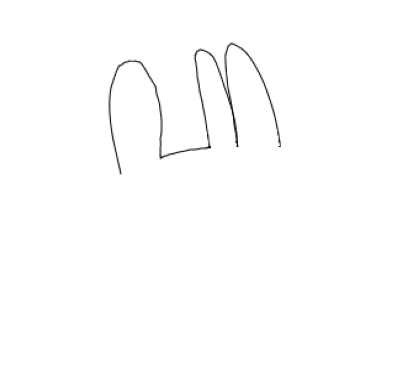

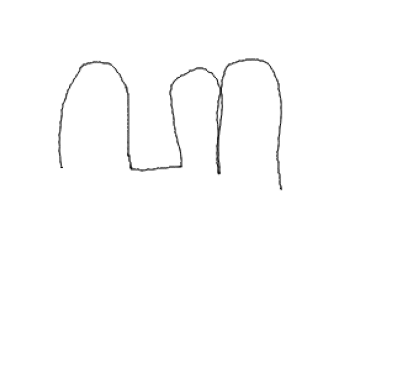

In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pic_index = 2

next_ha = [os.path.join(ha_dir, fname)
                for fname in ha_files[pic_index-2:pic_index]]
next_na = [os.path.join(na_dir, fname)
                for fname in na_files[pic_index-2:pic_index]]

next_ca = [os.path.join(ca_dir, fname)
           for fname in ca_files[pic_index-2:pic_index]]
next_ra = [os.path.join(ra_dir, fname) for fname in ra_files[pic_index-2:pic_index]]
next_ka = [os.path.join(ka_dir, fname) for fname in ka_files[pic_index-2:pic_index]]
next_da = [os.path.join(da_dir, fname) for fname in da_files[pic_index-2:pic_index]]
next_ta = [os.path.join(ta_dir, fname) for fname in ta_files[pic_index-2:pic_index]]
next_sa = [os.path.join(sa_dir, fname) for fname in sa_files[pic_index-2:pic_index]]
next_wa = [os.path.join(wa_dir, fname) for fname in wa_files[pic_index-2:pic_index]]
next_la = [os.path.join(la_dir, fname) for fname in la_files[pic_index-2:pic_index]]
next_pa = [os.path.join(pa_dir, fname) for fname in pa_files[pic_index-2:pic_index]]
next_dha = [os.path.join(dha_dir, fname) for fname in dha_files[pic_index-2:pic_index]]
next_ja = [os.path.join(ja_dir, fname) for fname in ja_files[pic_index-2:pic_index]]
next_ya = [os.path.join(ya_dir, fname) for fname in ya_files[pic_index-2:pic_index]]
next_nya = [os.path.join(nya_dir, fname) for fname in nya_files[pic_index-2:pic_index]]
next_ma = [os.path.join(ma_dir, fname) for fname in ma_files[pic_index-2:pic_index]]
next_ga = [os.path.join(ga_dir, fname) for fname in ga_files[pic_index-2:pic_index]]
next_ba = [os.path.join(ba_dir, fname) for fname in ba_files[pic_index-2:pic_index]]
next_tha = [os.path.join(tha_dir, fname) for fname in tha_files[pic_index-2:pic_index]]
next_nga = [os.path.join(nga_dir, fname) for fname in nga_files[pic_index-2:pic_index]]


for i, img_path in enumerate(next_ha):
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_width, img_height = 150, 150
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.2
)

train_dataset = train_datagen.flow_from_directory(
    '/content/train_data',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='sparse',
    subset='training'
)

validation_dataset = train_datagen.flow_from_directory(
    '/content/test_data',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation'
)


Found 3522 images belonging to 20 classes.
Found 1 images belonging to 20 classes.


In [40]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

model = tf.keras.models.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(20, activation='softmax')
])

# Print the model summary
model.summary()

# Set the training parameters
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 15, 15, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 5, 5, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 2, 2, 512)           │              

 Total params: 2,633,940 (10.05 MB)

 Trainable params: 2,630,932 (10.04 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [12]:
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
img_width = 150
img_height = 150


# Membuat dataset pelatihan dan validasi
train_dataset = image_dataset_from_directory(
    '/content/train_data',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_width, img_height),
    batch_size=32)

validation_dataset = image_dataset_from_directory(
    '/content/test_data',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_width, img_height),
    batch_size=32)

Found 4393 files belonging to 20 classes.
Using 3515 files for training.
Found 55 files belonging to 20 classes.
Using 11 files for validation.


In [41]:
# Callback untuk early stopping, reduce learning rate, dan model checkpoint
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# Training model
history = model.fit(
    train_dataset,
    #epochs=10,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)


# Evaluasi model
loss, accuracy = model.evaluate(validation_dataset)
print(f'Validation accuracy: {accuracy:.2f}')

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 338s 3s/step - accuracy: 0.1041 - loss: 4.8777 - val_accuracy: 0.1818 - val_loss: 5.8916 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 376s 3s/step - accuracy: 0.2942 - loss: 3.5660 - val_accuracy: 0.0909 - val_loss: 4.5272 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.4516 - loss: 2.8455 - val_accuracy: 0.2727 - val_loss: 3.3024 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.5508 - loss: 2.4236 - val_accuracy: 0.1818 - val_loss: 3.7868 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - accuracy: 0.6333 - loss: 2.0938 - val_accuracy: 0.4545 - val_loss: 2.8233 - learning_rate: 0.0010
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.7017 - loss: 1.8925 - val_accuracy: 0.2727 - val_loss: 4.2620 - learning_rate: 0.0010
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.7319 - l

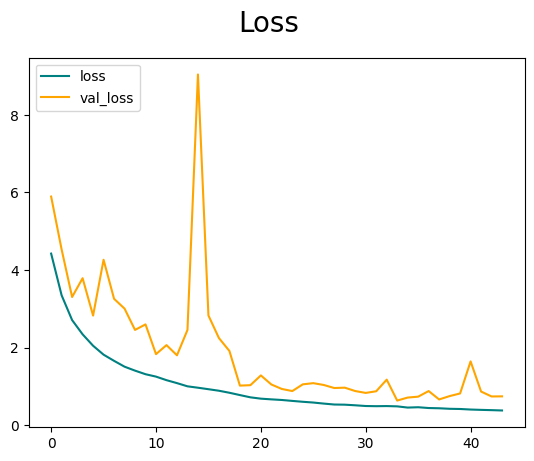

In [42]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

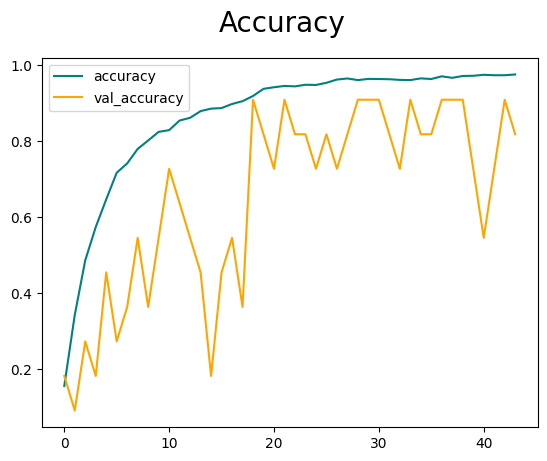

In [43]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [36]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Fungsi untuk memuat dan mempersiapkan gambar
def load_and_prepare_image(file_path, img_width, img_height):
    img = image.load_img(file_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Membuat batch yang terdiri dari satu gambar
    return img_array

# Memprediksi gambar baru
file_path = '/content/nya.png'  # Ganti dengan path ke gambar yang ingin diprediksi
img_width, img_height = 150, 150  # Ganti dengan dimensi yang sesuai dengan model
img_array = load_and_prepare_image(file_path, img_width, img_height)

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)

# Mendapatkan nama kelas dari class _names
predicted_class_name = train_dataset.class_names[predicted_class_index[0]]

print(f"Prediksi huruf Aksara Jawa: {predicted_class_name}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediksi huruf Aksara Jawa: nya


In [30]:
import os

# Check if a file exists
file_path = '/content/nya.png'

if os.path.exists(file_path):
    print(f"File {file_path} exists.")
else:
    print(f"File {file_path} does not exist.")


File /content/nya.png exists.


In [18]:
model.save('model.keras')

In [34]:
# Muat model yang telah disimpan dengan compile=False
model = tf.keras.models.load_model('/content/modelC.h5', compile=False)

# Konversi model ke TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TensorFlow Lite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpojkxkl8d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='conv2d_input')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  139978257011760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978256255104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978256266192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978256268304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978256261616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978256263904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978256317280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978256315344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978276425040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139978276423280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1399782764231

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

model = tf.keras.models.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(20, activation='softmax')
])

# Print the model summary
model.summary()

# Set the training parameters
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.save('modelB.h5')